In [ ]:
!pip install -r requirements.txt

In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoConfig, TrainingArguments, Trainer, BertModel, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pypinyin import pinyin, Style
import torch
import torch.nn as nn
import numpy as np
import evaluate
import pandas as pd
import os
import pronouncing

In [ ]:
# ============================================================
# DEVICE CONFIGURATION - Set USE_GPU to True if GPU available
# ============================================================
import torch

USE_GPU = True  # Set to True if you have GPU (CUDA/MPS)

# Detect available device
if USE_GPU:
    if torch.cuda.is_available():
        device = "cuda"
        print("✅ GPU (CUDA) detected and enabled")
    elif torch.backends.mps.is_available():
        device = "mps"  # Mac with Apple Silicon
        print("✅ GPU (MPS) detected and enabled")
    else:
        device = "cpu"
        print("⚠️ GPU requested but not available, falling back to CPU")
else:
    device = "cpu"
    print("✅ Using CPU (set USE_GPU=True to enable GPU)")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device.upper()}")

✅ GPU (CUDA) detected and enabled
PyTorch version: 2.10.0+cu128
Device: CUDA


In [ ]:
!pip install wandb

In [ ]:
import wandb

# Login to wandb
wandb.login()

# Initialize a wandb run
wandb.init(
    project="chinese-pun-toxic-detection",
    name="BERT+piying"
)

## PIYING PREPROCESSING

In [ ]:
map_dict = {
    'ㄅ': 'p', 'ㄆ': 'ph', 'ㄇ': 'm', 'ㄈ': 'f', 'ㄉ': 't','ㄊ': 'th', 'ㄋ': 'n',
    'ㄌ': 'l', 'ㄍ': 'k', 'ㄎ': 'kh', 'ㄏ': 'h', 'ㄐ': 'ts', 'ㄑ': 'tsh', 'ㄒ': 's',
    'ㄓ': 'tsr', 'ㄔ': 'tshr', 'ㄕ': 'sr', 'ㄖ': 'jr', 'ㄗ': 'ts', 'ㄘ': 'tsh', 'ㄙ': 's',
    'ㄚ': 'a', 'ㄛ': 'o', 'ㄜ': 'o', 'ㄝ': 'e', 'ㄞ': 'ai', 'ㄟ': 'ei', 'ㄠ': 'au', 'ㄡ': 'ou',
    'ㄢ': 'an', 'ㄣ': 'en', 'ㄤ': 'ang', 'ㄥ': 'eng', 'ㄦ': 'er', 'ㄧ': 'i', 'ㄨ': 'u', 'ㄩ': 'yu'
}

alpabet_to_pinyin = {
    "B": "ㄅ", "P": "ㄆ", "M": "ㄇ", "F": "ㄈ", "D": "ㄉ", "T": "ㄊ", "N": "ㄋ", "L": "ㄌ",
    "G": "ㄍ", "K": "ㄎ", "HH": "ㄏ", "JH": "ㄐ", "CH": "ㄔ", "ZH": "ㄓ", "SH": "ㄕ",
    "S": "ㄙ", "Z": "ㄗ", "TH": "ㄊ", "DH": "ㄉ", "V": "ㄈ", "W": "ㄨ", "Y": "ㄧ",
    "R": "ㄖ", "NG": "ㄥ", "AA": "ㄚ", "AE": "ㄝ", "AH": "ㄜ", "AO": "ㄛ", "AW": "ㄠ",
    "AY": "ㄞ", "EH": "ㄟ", "EY": "ㄟ", "IH": "ㄧ", "IY": "ㄧ", "OW": "ㄡ", "OY": "ㄡㄧ",
    "ER": "ㄦ", "UH": "ㄨ", "UW": "ㄨ"
}

In [ ]:
# Create phonetic vocabulary
unique_phonetics = set(map_dict.values())
p_vocab = {phonetic: i + 2 for i, phonetic in enumerate(sorted(unique_phonetics))}
p_vocab["[PAD]"] = 0
p_vocab["[UNK]"] = 1

In [ ]:
def handle_chinese(text):
    result = pinyin(text, style=Style.BOPOMOFO)
    piying = ""
    for char_list in result:
        for char in char_list[0]:
            if map_dict.get(char):
                piying += map_dict[char]
    return piying

def handle_english(text):
    phones = pronouncing.phones_for_word(text)
    p_rep = []
    if phones:
        for symbol in phones[0].split():
            base_symbol = symbol.rstrip("012")
            if base_symbol in alpabet_to_pinyin:
                p_rep.append(map_dict[alpabet_to_pinyin[base_symbol]])
    return "".join(p_rep)

def piying_preprocessing(text):
    if text.isascii():
        return handle_english(text.lower())
    return handle_chinese(text)


## Context Model

### Define Model

In [ ]:
import torch.nn as nn
from transformers import BertModel, BertPreTrainedModel, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback, PreTrainedConfig


In [ ]:
class PinyinBertClassifier(nn.Module):
    def __init__(self, config, pinyin_vocab_size):
        super().__init__()
        self.config = config
        self.bert = BertModel.from_pretrained("bert-base-chinese", config=config)
        self.pinyin_embeddings = nn.Embedding(pinyin_vocab_size, config.hidden_size)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, pinyin_ids=None, labels=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        p_embeds = self.pinyin_embeddings(pinyin_ids)

        # Fusion of semantic and phonetic features
        fused_output = sequence_output + p_embeds
        pooled_output = fused_output[:, 0, :] # [CLS] token
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))
        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

### Data Preprocessing

In [ ]:
data_path = "./toxic_dataset_cleaned.csv"
df = pd.read_csv(data_path).dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str)
df['label'] = df['label'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

dataset = DatasetDict({
    "train": Dataset.from_pandas(pd.DataFrame({"text": X_train.values, "label": y_train.values}), preserve_index=False),
    "validation": Dataset.from_pandas(pd.DataFrame({"text": X_val.values, "label": y_val.values}), preserve_index=False)
})

tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def preprocess_function(examples):
    result = tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
    all_pinyin_ids = []
    for text in examples["text"]:
        p_string = piying_preprocessing(text)
        ids = [p_vocab.get(char, 1) for char in p_string]
        ids = [0] + ids[:126] + [0] # Alignment with [CLS] and [SEP]
        ids += [0] * (128 - len(ids))
        all_pinyin_ids.append(ids)
    result["pinyin_ids"] = all_pinyin_ids
    return result

tokenized_dataset = dataset.map(preprocess_function, batched=True)


### Train

In [ ]:
config = AutoConfig.from_pretrained("bert-base-chinese", num_labels=2)
model = PinyinBertClassifier(config, pinyin_vocab_size=len(p_vocab)).to(device)

accuracy = evaluate.load("accuracy")
f1_macro = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_macro.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
args = TrainingArguments(
    output_dir="./models/toxic_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16 if device != "cpu" else 2,
    num_train_epochs=15 if device != "cpu" else 2,
    load_best_model_at_end=True,
    weight_decay=0.01,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.603262,0.703125,0.674431
2,No log,0.569289,0.687500,0.599499
3,No log,0.574445,0.750000,0.716501
4,No log,0.625234,0.734375,0.702326
5,No log,0.701801,0.742188,0.712712
6,No log,0.833775,0.734375,0.702326
7,No log,0.942631,0.734375,0.698782
8,No log,0.938146,0.734375,0.698782
9,No log,1.004915,0.765625,0.740260
10,No log,1.008352,0.773438,0.752781


TrainOutput(global_step=480, training_loss=0.1979718526204427, metrics={'train_runtime': 375.7659, 'train_samples_per_second': 20.279, 'train_steps_per_second': 1.277, 'total_flos': 0.0, 'train_loss': 0.1979718526204427, 'epoch': 15.0})

### Inference

In [ ]:
def predict(text):
    model.eval()
    # 1. 語義 Tokenization
    inputs = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128).to(device)

    # 2. 語音預處理 (與訓練邏輯對齊)
    p_string = piying_preprocessing(text)
    # 修正點：使用 p_vocab 且逐字對比 (不使用 .split())
    ids = [p_vocab.get(char, 1) for char in p_string]

    # 對齊 [CLS] 和 [SEP]，並補足長度至 128
    ids = [0] + ids[:126] + [0]
    ids += [0] * (128 - len(ids))
    p_ids = torch.tensor([ids]).to(device)

    # 3. 模型推論
    with torch.no_grad():
        out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], pinyin_ids=p_ids)
        logits = out["logits"]
        prediction = torch.argmax(logits, dim=-1).item()

        # 輸出易讀結果
        label_map = {0: "Non-Pun (非諧音)", 1: "Pun (諧音/毒性)"}
        return label_map[prediction]

In [ ]:
predict("你好")

'Pun (諧音/毒性)'

In [ ]:
# 11. Confusion Matrix & Classification Report
predictions = trainer.predict(tokenized_dataset["validation"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Non-Toxic", "Toxic"]))


Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.81      0.84      0.82        81
       Toxic       0.70      0.66      0.68        47

    accuracy                           0.77       128
   macro avg       0.76      0.75      0.75       128
weighted avg       0.77      0.77      0.77       128



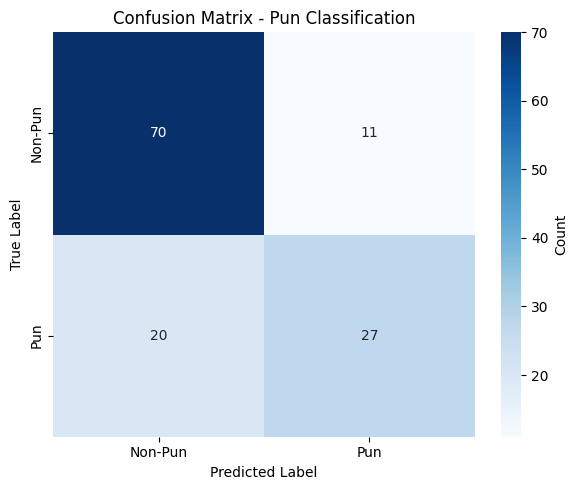


✅ Model training completed!


NameError: name 'output_dir' is not defined

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Pun", "Pun"],
            yticklabels=["Non-Pun", "Pun"],
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Pun Classification")
plt.tight_layout()
plt.show()

print("\n✅ Model training completed!")